# Name: Ansari Aatequa Mohammed Muzammil     

# Supervised ML Assignment

## Streamlit link
## life expectancy : https://life-expectancy-all-model-app.streamlit.app/


## a)	Describe the working of a Decision Tree algorithm. How does it decide on the best features to split the data? What are some advantages and disadvantages of using Decision Trees?

### A Decision Tree is a supervised machine learning algorithm that is used for both classification and regression problems. It works by splitting the data into smaller parts based on different conditions, and these splits form a tree-like structure.

### The top of the tree is called the root node, and from there the data is divided into branches based on feature values. This process continues until we reach the final nodes, called leaf nodes, which give the final prediction.

### The working of a Decision Tree is quite simple. First, it takes the entire dataset and checks which feature can best split the data. Then it divides the dataset based on that feature. After that, the same process is repeated for each subset of data. This continues until the data becomes pure (i.e., all values belong to the same class) or some stopping condition is met, like maximum depth.

### To decide the best feature for splitting, the algorithm uses certain measures:

### Gini Index: It measures how impure the data is. Lower value means better split.

### Entropy and Information Gain: Entropy measures the randomness in the data, and Information Gain tells how much the uncertainty is reduced after the split. The feature with highest Information Gain is selected.

### There are some advantages of Decision Trees. They are easy to understand and visualize. They do not require feature scaling and can handle both numerical and categorical data. Also, they can model non-linear relationships.

### However, there are also some disadvantages. Decision Trees can easily overfit the data, especially when the tree becomes too deep. They are also sensitive to small changes in the dataset, which can lead to a completely different tree. In many cases, their accuracy is lower compared to ensemble methods like Random Forest.

## ii.	Perform the EDA and do the visualizations.

## i.	Download the dataset from above link and load it into your Python environment.

In [68]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np

# Step 2: Load the dataset
df = pd.read_csv("Life Expectancy Data.csv")

# Step 3: View first 5 rows
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [69]:
df.shape

(2938, 22)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [71]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [72]:
df['Status'] = df['Status'].map({
    'Developing': 0,
    'Developed': 1
})

In [73]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [74]:
df = df.fillna(df.mean(numeric_only=True))

In [75]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')

#### Distribution of Target Variable

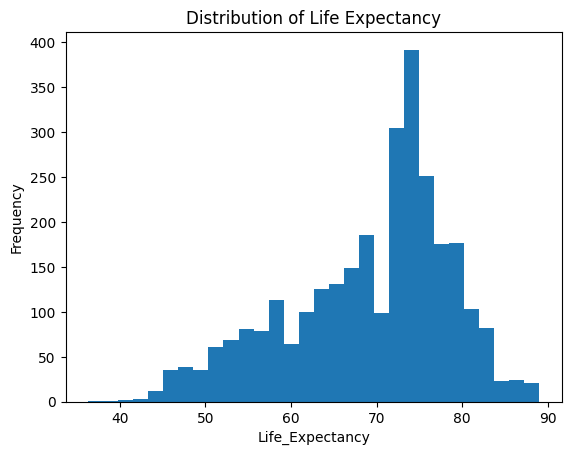

In [76]:
import matplotlib.pyplot as plt

plt.hist(df['Life_expectancy'], bins=30)
plt.xlabel("Life_Expectancy")
plt.ylabel("Frequency")
plt.title("Distribution of Life Expectancy")
plt.show()

#### Correlation Heatmap

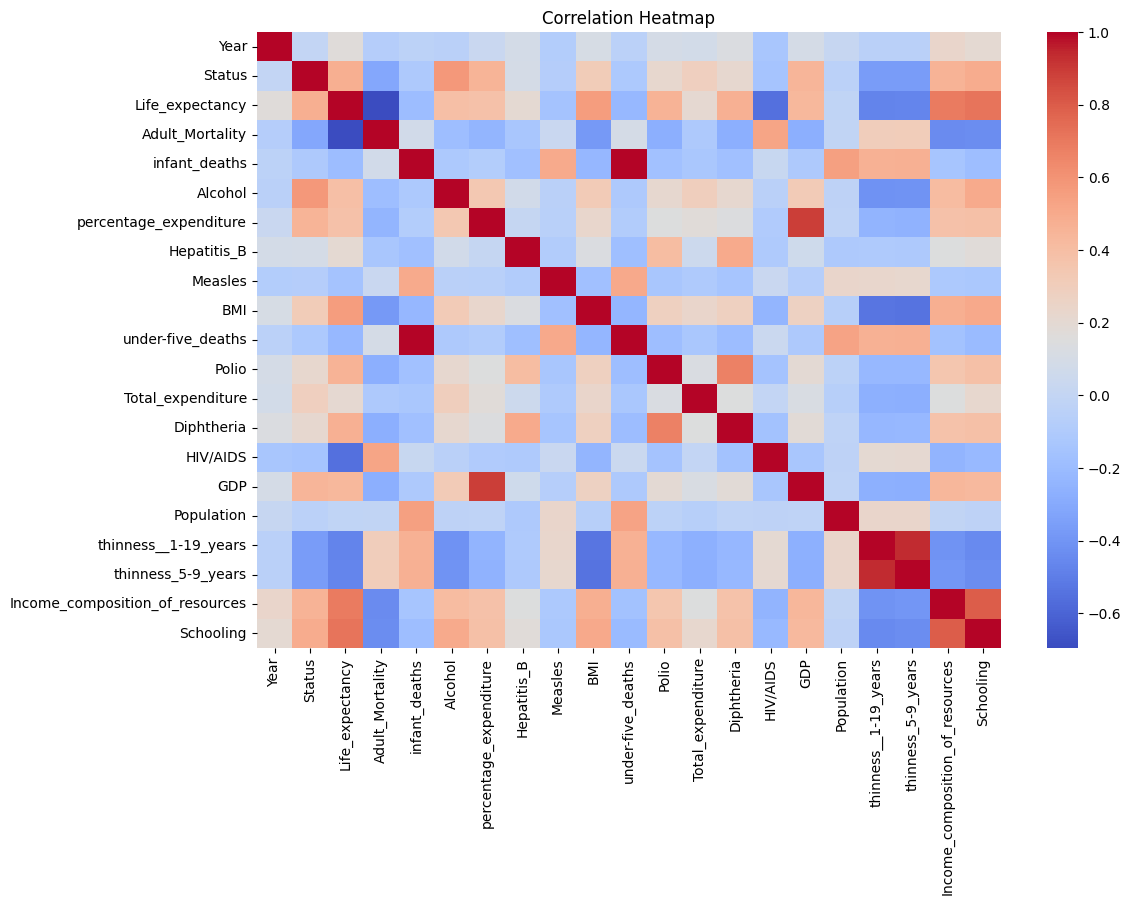

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Count Plot (Categorical Feature)

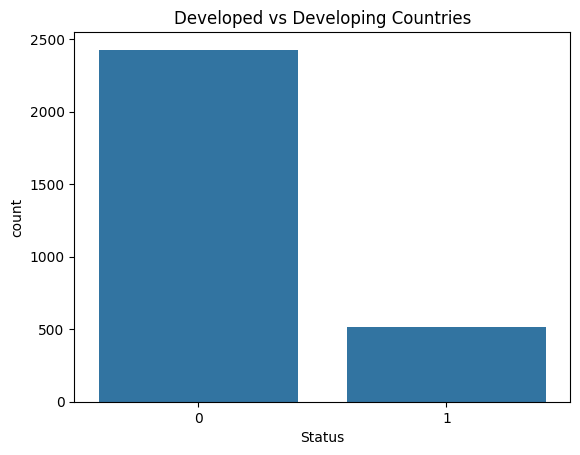

In [78]:
sns.countplot(x='Status', data=df)
plt.title("Developed vs Developing Countries")
plt.show()

### Scatter Plot

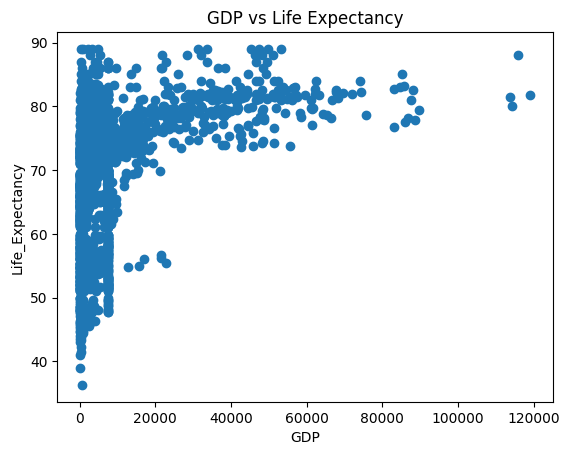

In [79]:
plt.scatter(df['GDP'], df['Life_expectancy'])
plt.xlabel("GDP")
plt.ylabel("Life_Expectancy")
plt.title("GDP vs Life Expectancy")
plt.show()

#### Boxplot (Outliers Detection)

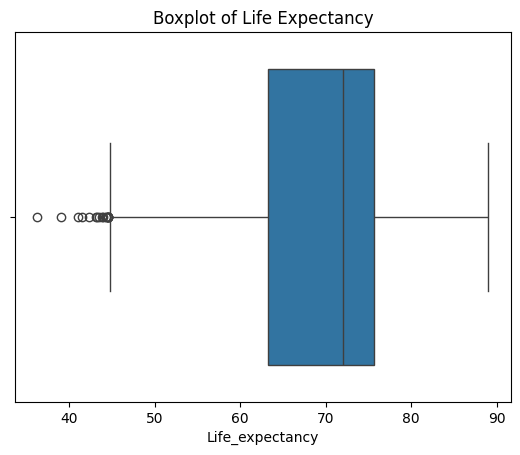

In [80]:
sns.boxplot(x=df['Life_expectancy'])
plt.title("Boxplot of Life Expectancy")
plt.show()

## iii.	Check the distributions/skewness in the variables and do the transformations if required.

#### Checking Skewness

In [81]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.skew()

Year                               -0.006409
Status                              1.718238
Life_expectancy                    -0.639693
Adult_Mortality                     1.176371
infant_deaths                       9.786963
Alcohol                             0.610026
percentage_expenditure              4.652051
Hepatitis_B                        -2.142780
Measles                             9.441332
BMI                                -0.220590
under-five_deaths                   9.495065
Polio                              -2.104863
Total_expenditure                   0.643921
Diphtheria                         -2.079481
HIV/AIDS                            5.396112
GDP                                 3.482880
Population                         18.041176
thinness__1-19_years                1.721451
thinness_5-9_years                  1.787788
Income_composition_of_resources    -1.177688
Schooling                          -0.619859
dtype: float64

#### Visualizing Distribution

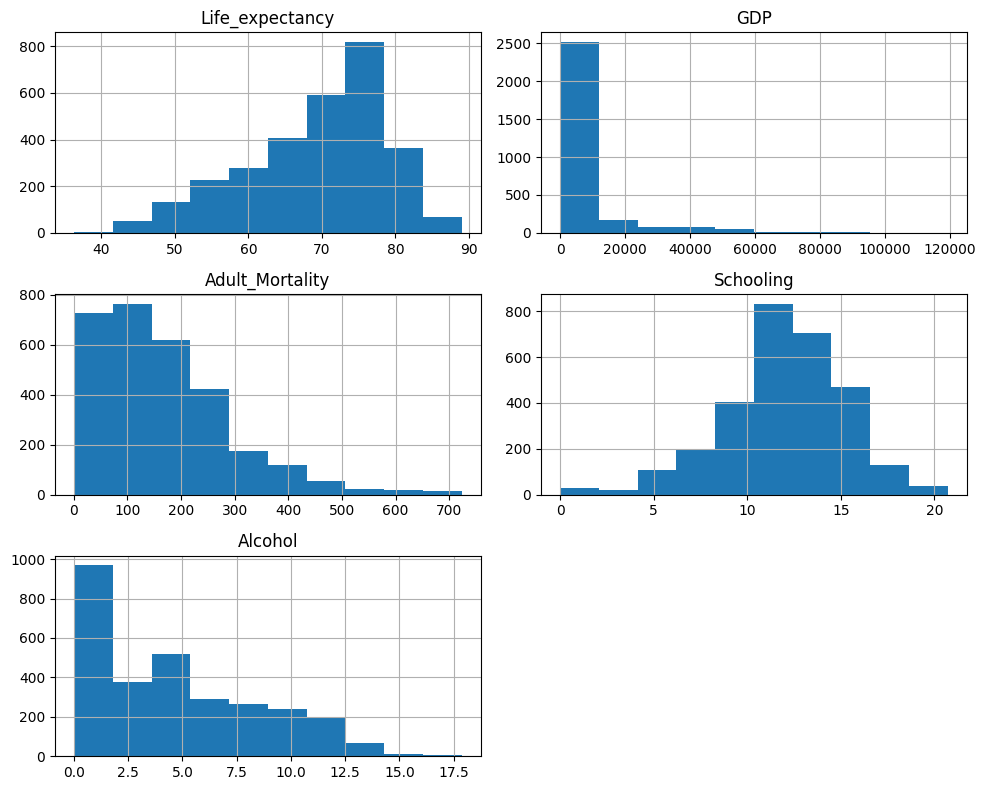

In [82]:
important_cols = [
    'Life_expectancy', 'GDP', 'Adult_Mortality', 
     'Schooling', 'Alcohol'
]

df[important_cols].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

#### Applying Transformation (Log Transformation)

In [83]:
import numpy as np

# Apply log transform directly on the main DataFrame (numeric_df is a separate copy)
# so that the transformation persists for downstream processing.
df['GDP'] = np.log1p(df['GDP'])
df['Population'] = np.log1p(df['Population'])

## iv.	Check/Treat the outliers and do the feature scaling if required.

In [84]:
df.columns

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality',
       'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B',
       'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='object')

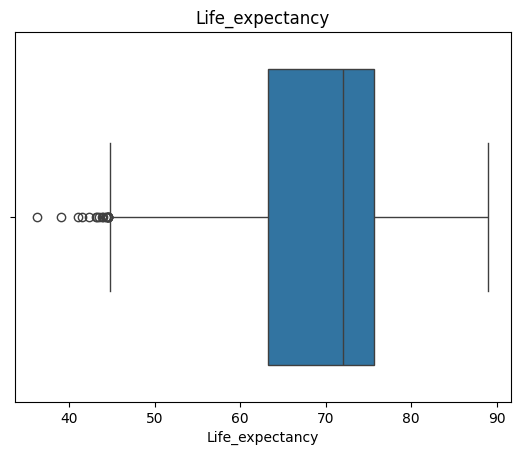

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

important_cols = ['Life_expectancy']

for col in important_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['number']).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [87]:
df.columns

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality',
       'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B',
       'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness__1-19_years',
       'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling'],
      dtype='object')

#### Standardization

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['number']).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

## v.	Create a ML model to predict the life expectancy based on the specifications given.

#### Remove Country

In [89]:
df = df.drop('Country', axis=1)

### Define X and y

In [90]:
X = df.drop('Life_expectancy', axis=1)
y = df['Life_expectancy']

### Train-Test Split

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Train Model

In [92]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Prediction + Evaluation

In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.29931531512979437
RMSE: 0.4073371470233992
R2 Score: 0.8269343467579955


## vi.	Check for overfitting and treat them accordingly.

#### Check Train vs Test Performance

In [94]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

from sklearn.metrics import r2_score

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train R2: 0.8203763978784535
Test R2: 0.8269343467579955


#### Apply Ridge Regression

In [95]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, ridge_pred))

Ridge R2: 0.8263836572109856


### Apply Lasso Regression

In [96]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))

Lasso R2: 0.7828507377716712


#### vii.	Use all the Supervised ML algorithms (DT, RF, SVM, XGBoost etc.) and compare the performances to get the best model.

In [97]:
import sys
!{sys.executable} -m pip install xgboost

In [98]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [99]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
svm = SVR()
xgb = XGBRegressor()

In [100]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb
}

In [101]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "R2 Score:", r2_score(y_test, pred))

Decision Tree R2 Score: 0.8968317768738
Random Forest R2 Score: 0.9683275587036108
SVM R2 Score: 0.9335730122909032
XGBoost R2 Score: 0.964820136800931


In [102]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = r2_score(y_test, pred)
    results.append([name, score])

import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "R2 Score"])
results_df

,Model,R2 Score
0,Decision Tree,0.896832
1,Random Forest,0.968328
2,SVM,0.933573
3,XGBoost,0.964820


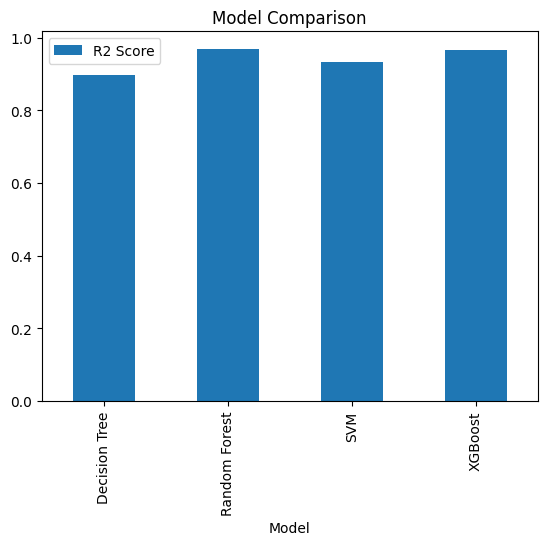

In [103]:
results_df.plot(x="Model", y="R2 Score", kind="bar")
plt.title("Model Comparison")
plt.show()

In [104]:
import pickle

# Train models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

lr = LinearRegression().fit(X_train, y_train)
dt = DecisionTreeRegressor(max_depth=5).fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=100).fit(X_train, y_train)
svm = SVR().fit(X_train, y_train)

# Save all models in dictionary
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm
}

with open("all_models.pkl", "wb") as f:
    pickle.dump(models, f)

# Save columns
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

## c)	Use the Income Classification dataset from below Kaggle link and create an end to end project on Jupyter/Colab.



#### i.	Download the dataset from above link and load it into your Python environment 

In [105]:

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("income_evaluation.csv")

# View first 5 rows
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


#### ii.	Perform the EDA and do the visualizations.

In [106]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [107]:
df.shape


(32561, 15)

In [108]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [109]:
# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('-', '_')
df.columns = df.columns.str.replace(' ', '_')

# Remove spaces in data
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

In [110]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [111]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

## Distribution of Target Variable

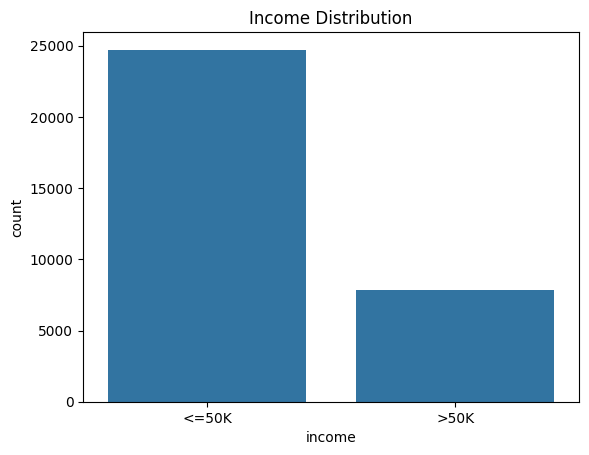

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='income', data=df)
plt.title("Income Distribution")
plt.show()

#### Numerical Features Distribution

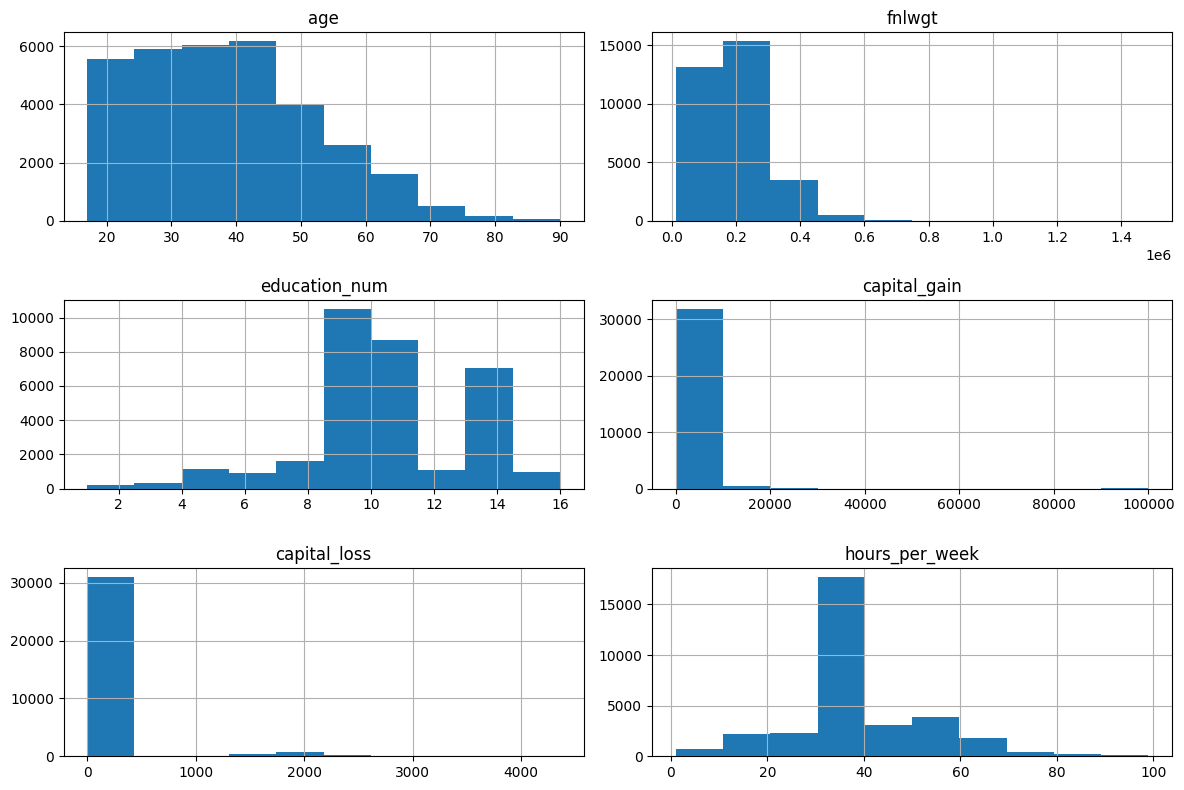

In [113]:
num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

### Categorical Features Analysis

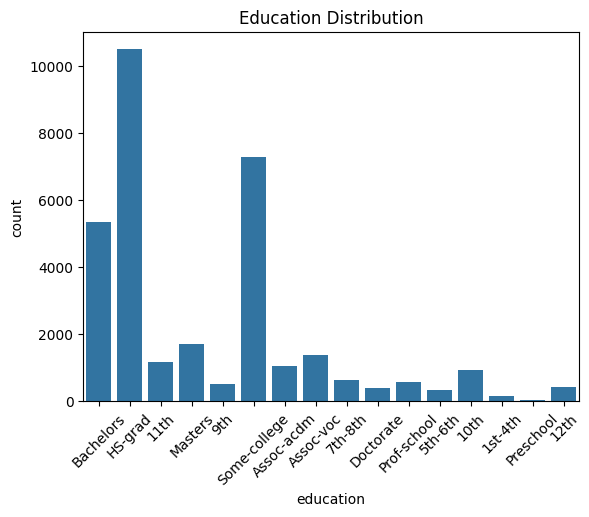

In [114]:
sns.countplot(x='education', data=df)
plt.xticks(rotation=45)
plt.title("Education Distribution")
plt.show()

#### Relationship with Target

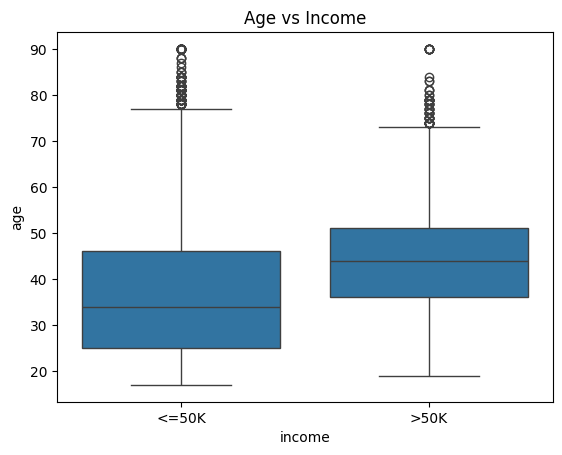

In [115]:
sns.boxplot(x='income', y='age', data=df)
plt.title("Age vs Income")
plt.show()

#### Correlation Heatmap

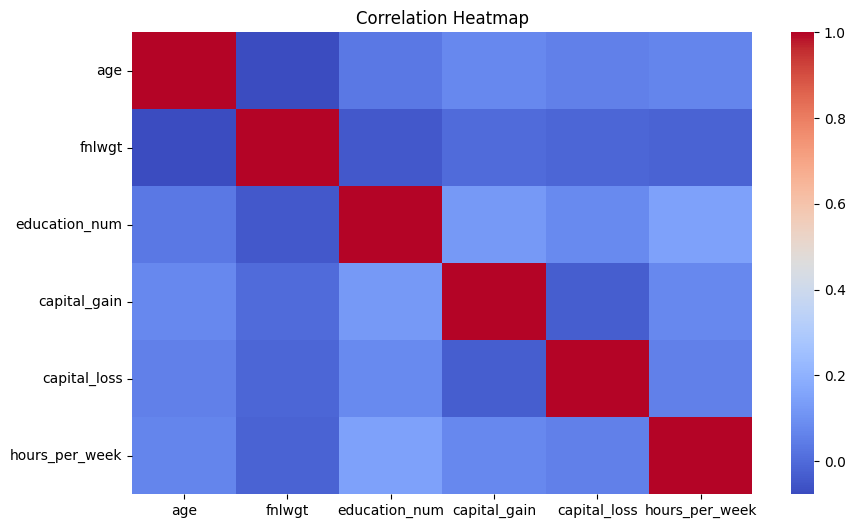

In [116]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### iii.	Check the distributions/skewness in the variables and do the transformations if required.

In [117]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.skew()

age                0.558743
fnlwgt             1.446980
education_num     -0.311676
capital_gain      11.953848
capital_loss       4.594629
hours_per_week     0.227643
dtype: float64

### Visualize Distributions

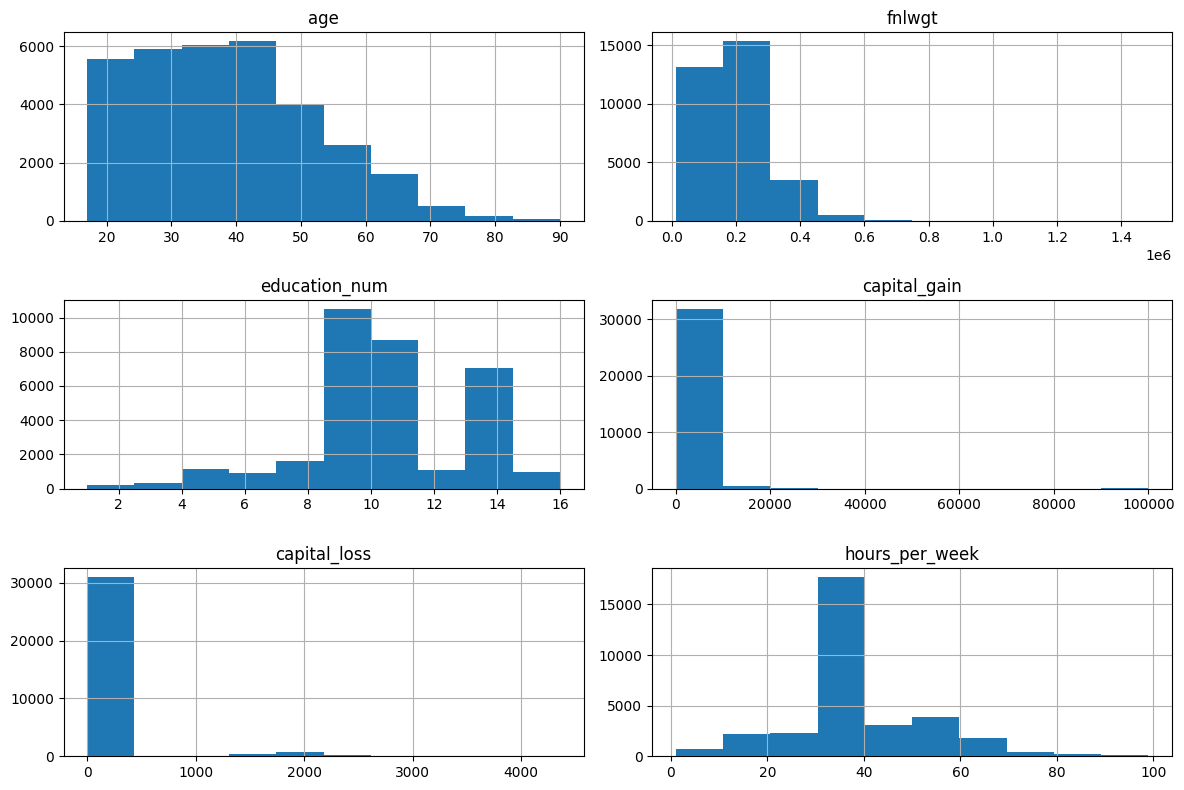

In [118]:
numeric_df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

#### Apply Transformation

In [119]:
import numpy as np

df['capital_gain'] = np.log1p(df['capital_gain'])
df['capital_loss'] = np.log1p(df['capital_loss'])

### Re-check Distribution

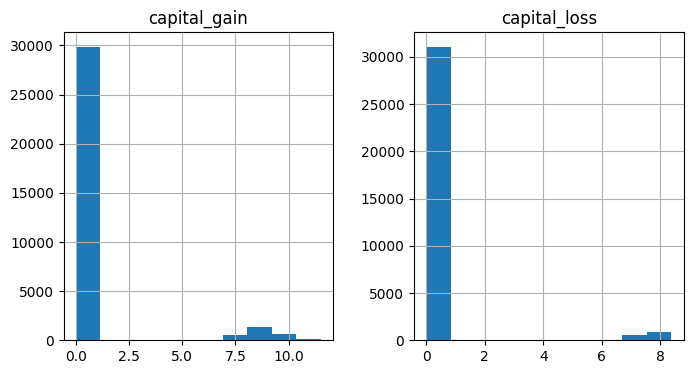

In [120]:
df[['capital_gain', 'capital_loss']].hist(figsize=(8,4))
plt.show()

## iv.	Check/Treat the outliers and do the feature scaling if required.

### Detect Outliers using Boxplot

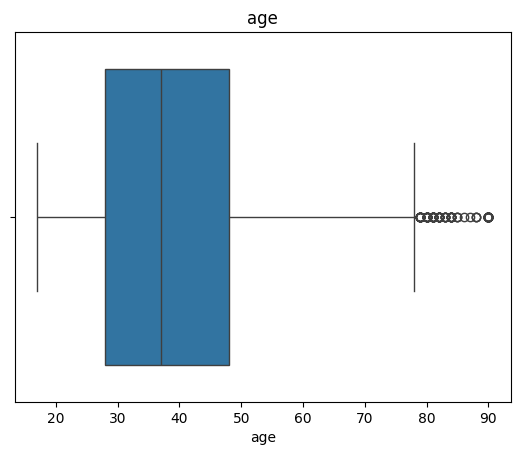

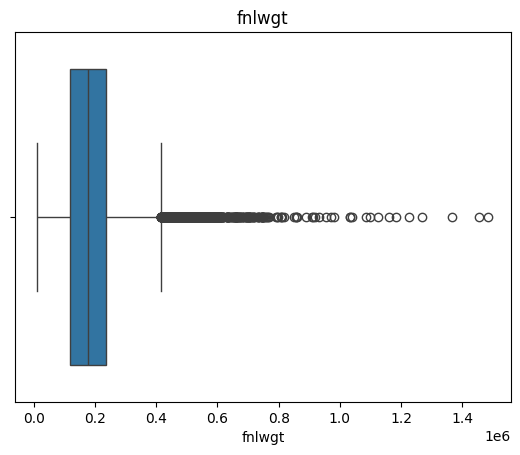

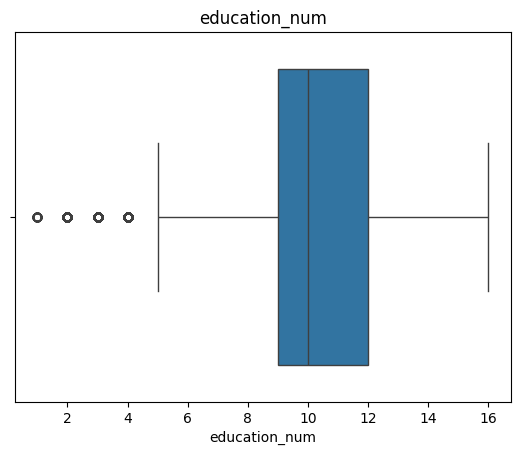

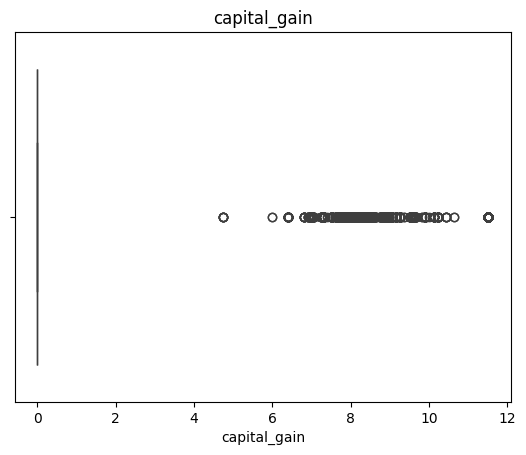

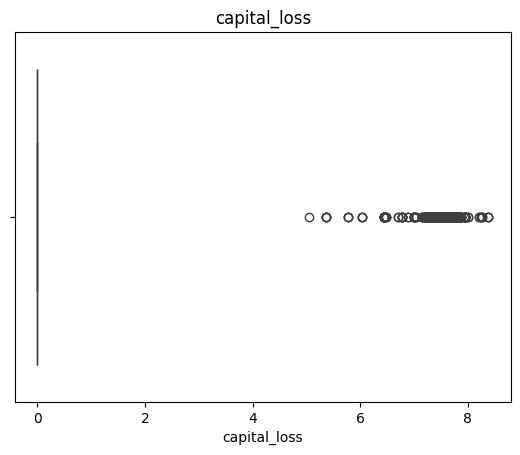

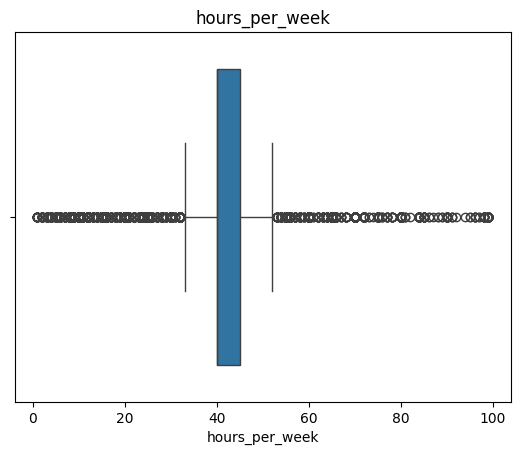

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Treat Outliers (IQR Method)

In [122]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

# Apply to selected columns
for col in num_cols:
    df = remove_outliers(df, col)

### Standardization

In [126]:
df.select_dtypes(include=['object'])
df = pd.get_dummies(df, drop_first=True)
X = df.drop('income_>50K', axis=1)
y = df['income_>50K']
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### v.	Create a ML model to do the income classification based on the specifications given.

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [128]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [129]:
y_pred = model.predict(X_test)

In [130]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8474085766903446

Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.94      0.91      3019
        True       0.68      0.49      0.57       782

    accuracy                           0.85      3801
   macro avg       0.78      0.72      0.74      3801
weighted avg       0.84      0.85      0.84      3801



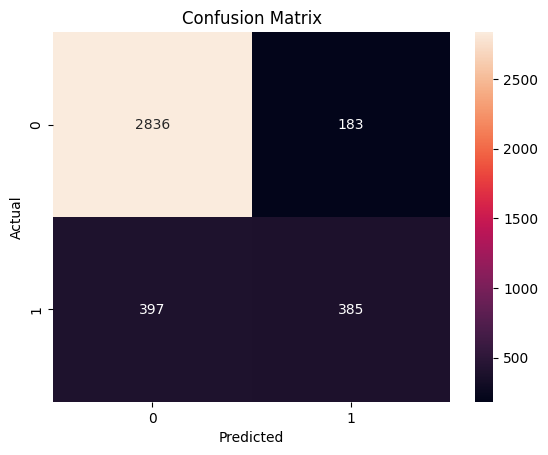

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### vi.	Check for overfitting and treat them accordingly.

#### Compare Train vs Test Accuracy

In [132]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.8402946786818392
Test Accuracy: 0.8474085766903446


#### Use Regularization

In [133]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=0.1, max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### vii.	Use all the Supervised ML algorithms (DT, RF, SVM, XGBoost etc.) and compare the performances to get the best model.

In [135]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [136]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC()
xgb = XGBClassifier()

In [138]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "XGBoost": xgb
}

In [139]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append([name, acc])

import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

,Model,Accuracy
2,SVM,0.843725
3,XGBoost,0.840305
0,Decision Tree,0.828729
1,Random Forest,0.825835


In [141]:
with open("income_models.pkl", "wb") as f:
    pickle.dump(models, f)

# ==============================
# 11. SAVE COLUMNS
# ==============================
with open("income_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

# ==============================
# 12. SAVE SCALER (IMPORTANT)
# ==============================
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("\n✅ All models saved successfully!")


✅ All models saved successfully!


## d)	What is the difference between Bagging Classifier and voting classifier. Explain the working of both the algorithms.

| Basis                      | Bagging Classifier                                                                                                                                       | Voting Classifier                                                                                                                       |
| -------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| **Definition**             | Bagging (Bootstrap Aggregating) is an ensemble technique where multiple models of the **same type** are trained on different random subsets of the data. | Voting is an ensemble technique where multiple **different models** are trained on the same dataset and their predictions are combined. |
| **Type of Models Used**    | Uses **homogeneous models** (same algorithm, e.g., Decision Trees).                                                                                      | Uses **heterogeneous models** (different algorithms like Logistic Regression, SVM, Decision Tree).                                      |
| **Training Data**          | Each model is trained on a **different subset** of the dataset created using bootstrap sampling.                                                         | All models are trained on the **same dataset**.                                                                                         |
| **Sampling Technique**     | Uses **bootstrap sampling (with replacement)** to create multiple datasets.                                                                              | No sampling is used; same data is given to all models.                                                                                  |
| **Main Objective**         | Reduces **variance** and helps in handling overfitting.                                                                                                  | Improves **overall accuracy** by combining strengths of different models.                                                               |
| **Prediction Method**      | Final prediction is made by **majority voting (classification)** or **averaging (regression)**.                                                          | Final prediction is made using **hard voting (majority)** or **soft voting (probability averaging)**.                                   |
| **Overfitting Handling**   | Effectively reduces overfitting, especially for high-variance models.                                                                                    | May or may not reduce overfitting depending on models used.                                                                             |
| **Example**                | Random Forest is a classic example of Bagging.                                                                                                           | Voting Classifier (combining LR + SVM + DT) is an example.                                                                              |
| **Model Diversity Source** | Diversity comes from **different data samples**.                                                                                                         | Diversity comes from **different algorithms**.                                                                                          |


## Working of Bagging

The dataset is randomly sampled with replacement (bootstrap sampling)

Multiple subsets of data are created

The same base model (e.g., Decision Tree) is trained on each subset

Predictions from all models are combined

Classification → Majority voting

Regression → Average

## Working of Voting

Different models are trained on the same dataset

Example: Logistic Regression, SVM, Decision Tree

Each model makes a prediction

Final prediction is decided by:

Hard Voting → Majority vote

Soft Voting → Average of probabilities

### e)	Explain the Bayes theorem in Naïve Bayes Algorithm.

#### Naïve Bayes is a probabilistic machine learning algorithm based on Bayes Theorem, which is used to calculate the probability of a class given a set of input features.By assuming feature independence, it simplifies computation and works efficiently for classification problems.

### Working of Naïve Bayes Algorithm

Calculate the prior probability of each class

Calculate the likelihood of each feature given the class

Apply Bayes theorem to compute posterior probability

Select the class with the highest probability